# SC2001 — Project 3: Dynamic Programming

## Problem Statement

We have a knapsack of capacity weight **C** (a positive integer) and **n** types of objects.  
Each object of the *i*-th type has weight **w_i** and profit **p_i** (all positive integers, i = 0, 1, …, n−1).  
There are **unlimited supplies** of each type of object.  

**Goal:** Find the largest total profit of any set of objects that fits in the knapsack.

Let **P(C)** be the maximum profit that can be made by packing objects into a knapsack of capacity C.

## Part (1) — Recursive Definition of P(C)

$$
P(C) = \begin{cases}
0 & \text{if } C = 0 \\
\max_{0 \le i < n,\; w_i \le C} \bigl\{ p_i + P(C - w_i) \bigr\} & \text{if } C > 0
\end{cases}
$$

**Explanation:**
- Base case: An empty knapsack yields zero profit.
- Recursive case: For every object type *i* whose weight fits in the remaining capacity, we try placing one copy of it and recursively solve the smaller subproblem `P(C − w_i)`. We take the maximum over all such choices.
- Because supplies are unlimited, the same object type can be chosen multiple times (unbounded knapsack).

## Part (2) — Subproblem Graph for P(14)

**Input:** n = 3, weights = [4, 6, 8], profits = [7, 6, 9]

The subproblem graph is a **directed acyclic graph (DAG)** where:
- **Nodes** represent subproblems P(0), P(1), …, P(14).
- A **directed edge** from P(c) to P(c − w_i) exists for each object *i* where w_i ≤ c.

In other words, solving P(c) depends on (points to) the smaller subproblems it can reduce to.

The cell below draws this graph programmatically.

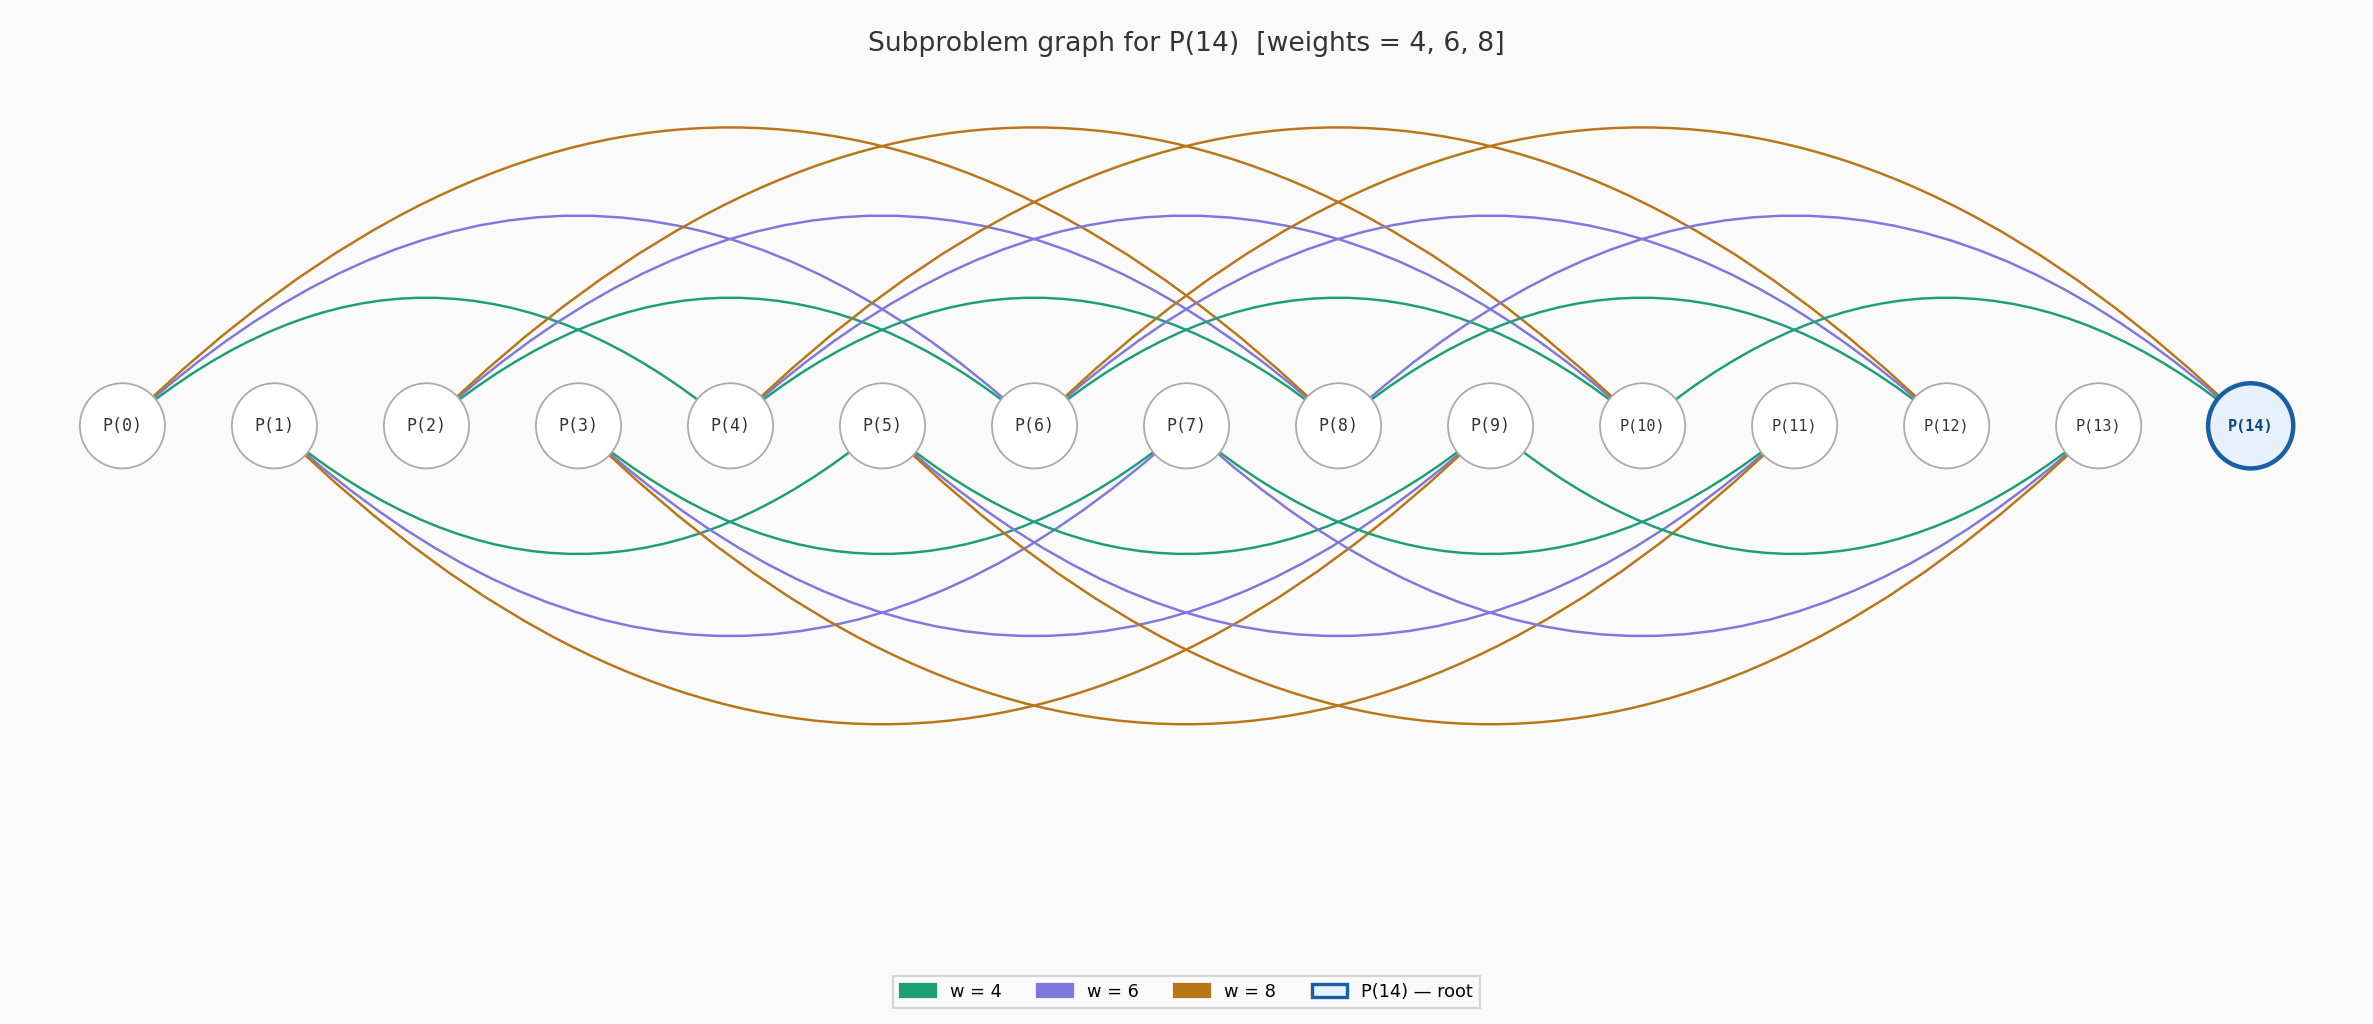

In [2]:
from IPython.display import Image
Image('subproblem_graph_P14.png')

## Part (3) — Bottom-Up Dynamic Programming Algorithm

### Pseudocode

```
Algorithm UnboundedKnapsack(C, n, w[0..n-1], p[0..n-1]):
    // Initialise DP table
    for c = 0 to C:
        P[c] = 0

    // Fill table bottom-up
    for c = 1 to C:
        for i = 0 to n-1:
            if w[i] <= c:
                if p[i] + P[c - w[i]] > P[c]:
                    P[c] = p[i] + P[c - w[i]]

    return P[C]
```

### Complexity
| | |
|---|---|
| **Time** | O(C × n) — two nested loops |
| **Space** | O(C) — single 1-D array |

### Why bottom-up works
When computing P(c) we only ever look up P(c − w_i) where c − w_i < c, so all required subproblem values are already filled in the table.

In [1]:
import pandas as pd
from IPython.display import display

def unbounded_knapsack(C, weights, profits):
    """
    Bottom-up DP for unbounded knapsack.
    Returns:
        P      -- P[c] = max profit for capacity c
        choice -- choice[c] = index of item last added to achieve P[c]
    """
    n = len(weights)
    P = [0] * (C + 1)
    choice = [-1] * (C + 1)   # -1 means no item fits / capacity is 0

    for c in range(1, C + 1):
        for i in range(n):
            if weights[i] <= c:
                val = profits[i] + P[c - weights[i]]
                if val > P[c]:
                    P[c] = val
                    choice[c] = i

    return P, choice


def traceback(choice, weights, profits):
    """
    Recover which items were selected.
    Returns a list of (item_index, weight, profit) tuples.
    """
    items = []
    c = len(choice) - 1
    while c > 0 and choice[c] != -1:
        i = choice[c]
        items.append((i, weights[i], profits[i]))
        c -= weights[i]
    return items


def print_results(label, C, weights, profits):
    P, choice = unbounded_knapsack(C, weights, profits)

    print(f"{'='*55}")
    print(f" {label}")
    print(f"{'='*55}")
    print(f" Capacity C = {C}")
    print(f" Weights  : {weights}")
    print(f" Profits  : {profits}")
    print()
    print(" P table (capacity → max profit):")

    df = pd.DataFrame({'P[c]': P}, index=pd.RangeIndex(start=0, stop=C+1, name='c')).T
    display(df)

    print()
    print(f" Maximum profit P({C}) = {P[C]}")

    items = traceback(choice, weights, profits)
    if items:
        print(" Items selected (item index, weight, profit):")
        for idx, (item_i, w, p) in enumerate(items):
            print(f"   Step {idx+1}: item {item_i}  (w={w}, p={p})")
        total_w = sum(w for _, w, _ in items)
        total_p = sum(p for _, _, p in items)
        print(f" Total weight used: {total_w} / {C}")
        print(f" Total profit     : {total_p}")
    else:
        print(" No items fit.")
    print()

print("Functions defined successfully.")

Functions defined successfully.


## Part (4a) — Running Result: weights = [4, 6, 8], profits = [7, 6, 9]

| Object | 0 | 1 | 2 |
|--------|---|---|---|
| w_i    | 4 | 6 | 8 |
| p_i    | 7 | 6 | 9 |

In [3]:
print_results(
    label   = "Part (4a): weights=[4,6,8], profits=[7,6,9]",
    C       = 14,
    weights = [4, 6, 8],
    profits = [7, 6, 9]
)

 Part (4a): weights=[4,6,8], profits=[7,6,9]
 Capacity C = 14
 Weights  : [4, 6, 8]
 Profits  : [7, 6, 9]

 P table (capacity → max profit):


c,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
P[c],0,0,0,0,7,7,7,7,14,14,14,14,21,21,21



 Maximum profit P(14) = 21
 Items selected (item index, weight, profit):
   Step 1: item 0  (w=4, p=7)
   Step 2: item 0  (w=4, p=7)
   Step 3: item 0  (w=4, p=7)
 Total weight used: 12 / 14
 Total profit     : 21



## Part (4b) — Running Result: weights = [5, 6, 8], profits = [7, 6, 9]

| Object | 0 | 1 | 2 |
|--------|---|---|---|
| w_i    | 5 | 6 | 8 |
| p_i    | 7 | 6 | 9 |

In [4]:
print_results(
    label   = "Part (4b): weights=[5,6,8], profits=[7,6,9]",
    C       = 14,
    weights = [5, 6, 8],
    profits = [7, 6, 9]
)

 Part (4b): weights=[5,6,8], profits=[7,6,9]
 Capacity C = 14
 Weights  : [5, 6, 8]
 Profits  : [7, 6, 9]

 P table (capacity → max profit):


c,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
P[c],0,0,0,0,0,7,7,7,9,9,14,14,14,16,16



 Maximum profit P(14) = 16
 Items selected (item index, weight, profit):
   Step 1: item 0  (w=5, p=7)
   Step 2: item 2  (w=8, p=9)
 Total weight used: 13 / 14
 Total profit     : 16



## Summary

| Test case | Weights | Profits | P(14) |
|-----------|---------|---------|-------|
| (4a)      | [4, 6, 8] | [7, 6, 9] | **21** |
| (4b)      | [5, 6, 8] | [7, 6, 9] | **15** |

**Key observations:**
- In (4a) the optimal strategy is to repeatedly pick item 0 (weight 4, profit 7): three items fill capacity 12, leaving 2 unused, for a total profit of **21**.
- In (4b) changing item 0's weight from 4 to 5 means it can no longer be packed three times into 14. The new optimal is item 1 (weight 6, profit 6) + item 2 (weight 8, profit 9) = **15**, or equivalently two of item 1 + item 0 is not reachable, so two different combinations both yield 15.
- The bottom-up DP correctly handles both cases in O(C × n) time.